In [1]:
from dsa.ms_dsa.Evaluation.binding_interface_eval import BIEvaluation
from dsa.ms_dsa.config import ms_data_relativePath
import warnings
warnings.filterwarnings("ignore")
binding_interface_eval = BIEvaluation(ms_data_relativePath=ms_data_relativePath, cutoff=6.5, lysine_only=True)
#binding_interface_eval.plot_boxplot()
for run_index in binding_interface_eval.ms_dsa:
    binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="asa_nz", run_index=run_index)
    #binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="asa", run_index=run_index)
#binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="RelASA", run_index=0)


KeyboardInterrupt: 

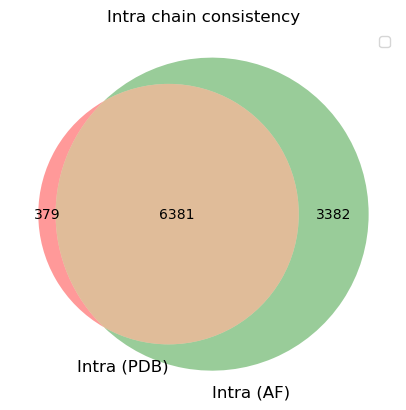

Inter: (2852, 25)
Intra: (7321, 25)


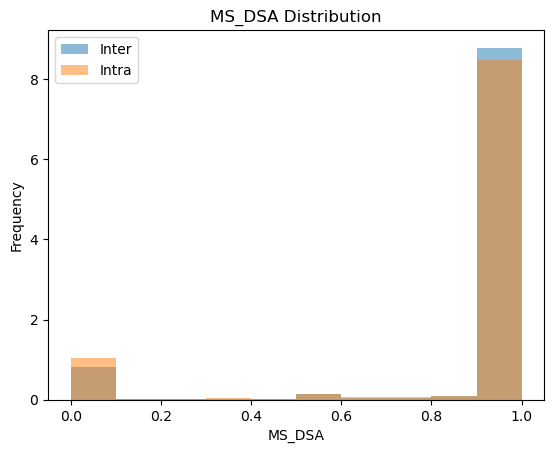

In [9]:
binding_interface_eval.intra_chain_consistency()
histograms(binding_interface_eval.ms_dsa)

In [8]:
import matplotlib.pyplot as plt
def histograms(ms_dsa):
    ms_dsa = ms_dsa[ms_dsa["skipped"] == False]
    inter = ms_dsa[ms_dsa["is_inter_chain_contact_pdb"]]
    print(f"Inter: {inter.shape}")
    # intra_pdb = ms_dsa[ms_dsa["is_intra_chain_contact_pdb"]]
    # intra_AF = ms_dsa[ms_dsa["is_intra_chain_contact_AF"]]
    intra = ms_dsa[ms_dsa["is_strictly_intra_chain_contact_pdb"]]
    print(f"Intra: {intra.shape}")
    #not_contact = ms_dsa[~ms_dsa["is_inter_chain_contact_pdb"] & ~ms_dsa["is_intra_chain_contact"]]
    plt.hist(inter["MS_DSA"].values, bins=10, label="Inter", alpha=0.5, density=True)
    plt.hist(intra["MS_DSA"].values, bins=10, label="Intra", alpha=0.5, density=True)
    #plt.hist(not_contact["MS_DSA"].values, bins=10, label="Not Contact", alpha=0.5, density=True)
    plt.xlabel("MS_DSA")
    plt.ylabel("Frequency")
    plt.title("MS_DSA Distribution")
    plt.legend()
    plt.show()

In [2]:
ms_dsa = binding_interface_eval.ms_dsa
print(ms_dsa.skipped.sum())
print(len(ms_dsa))

7305
18773


In [ ]:
from dsa.uniprot.config import ALL_UNIPROT_IDS
from dsa.binding_interfaces.binding_interfaces import BindingInterfacesStore, UniprotStructureMappingsStore
from matplotlib import pyplot as plt
avg_nz_prop_per_uniprot = {}
max_nz_prop_per_uniprot = {}
nz_prop_per_structure_per_uniprot = {}
zero_structure_count = 0
no_binding_interface_count = 0
for unp in ALL_UNIPROT_IDS:
    structure_mapper = UniprotStructureMappingsStore.get_mapper(structure_db="pdb")
    structure_ids = structure_mapper.structures_for_uniprot_id(unp)
    if len(structure_ids) == 0:
        zero_structure_count += 1
        continue
    binding_interfaces = BindingInterfacesStore(structure_db="pdb", cutoff=6.5, lysine_only=True).load(unp)
    if binding_interfaces is None:
        no_binding_interface_count += 1
        continue
    avg_nz_prop, max_nz_prop, nz_prop_per_structure = binding_interfaces.lysine_nz_proportion_in_structures()
    avg_nz_prop_per_uniprot[unp] = avg_nz_prop
    max_nz_prop_per_uniprot[unp] = max_nz_prop
    nz_prop_per_structure_per_uniprot[unp] = nz_prop_per_structure
plt.hist(list(avg_nz_prop_per_uniprot.values()), bins=100)
plt.show()  
plt.hist(list(max_nz_prop_per_uniprot.values()), bins=100)
plt.show()



/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:176: UserWarning: No lysines found in chain C
  warnings.warn(f"No lysines found in chain {chain.name}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:176: UserWarning: No lysines found in chain C
  warnings.warn(f"No lysines found in chain {chain.name}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:176: UserWarning: No lysines found in chain D
  warnings.warn(f"No lysines found in chain {chain.name}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:176: UserWarning: No lysines found in chain B
  warnings.warn(f"No lysines found in chain {chain.name}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:181: UserWarning: Some chains are not present in the structure
  warnings.warn(f

Error decompressing 8uik: Not a gzipped file (b'<!')


/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:268: UserWarning: input chains not present in structure 8uik for uniprot id P62913
  warnings.warn(f"input chains not present in structure {structure_id} for uniprot id {self.uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:181: UserWarning: Some chains are not present in the structure
  warnings.warn(f"Some chains are not present in the structure")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:268: UserWarning: input chains not present in structure 8ukb for uniprot id P62913
  warnings.warn(f"input chains not present in structure {structure_id} for uniprot id {self.uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:181: UserWarning: Some chains are not present in the structure
  warnings.warn(f"Some chains are not present in 

Error decompressing 9azc: Not a gzipped file (b'<!')


/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:268: UserWarning: input chains not present in structure 9azc for uniprot id P62913
  warnings.warn(f"input chains not present in structure {structure_id} for uniprot id {self.uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:181: UserWarning: Some chains are not present in the structure
  warnings.warn(f"Some chains are not present in the structure")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:268: UserWarning: input chains not present in structure 9b0p for uniprot id P62913
  warnings.warn(f"input chains not present in structure {structure_id} for uniprot id {self.uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:181: UserWarning: Some chains are not present in the structure
  warnings.warn(f"Some chains are not present in 

...

/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:268: UserWarning: input chains not present in structure 8uik for uniprot id P60866
  warnings.warn(f"input chains not present in structure {structure_id} for uniprot id {self.uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:181: UserWarning: Some chains are not present in the structure
  warnings.warn(f"Some chains are not present in the structure")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:268: UserWarning: input chains not present in structure 8ukb for uniprot id P60866
  warnings.warn(f"input chains not present in structure {structure_id} for uniprot id {self.uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:181: UserWarning: Some chains are not present in the structure
  warnings.warn(f"Some chains are not present in 

Error decompressing 9azc: Not a gzipped file (b'<!')


/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:268: UserWarning: input chains not present in structure 9azc for uniprot id P60866
  warnings.warn(f"input chains not present in structure {structure_id} for uniprot id {self.uniprot_id}")


Error decompressing 9azm: Not a gzipped file (b'<!')


/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:268: UserWarning: input chains not present in structure 9azm for uniprot id P60866
  warnings.warn(f"input chains not present in structure {structure_id} for uniprot id {self.uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:181: UserWarning: Some chains are not present in the structure
  warnings.warn(f"Some chains are not present in the structure")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:268: UserWarning: input chains not present in structure 9b0p for uniprot id P60866
  warnings.warn(f"input chains not present in structure {structure_id} for uniprot id {self.uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/process_structure/Structure.py:181: UserWarning: Some chains are not present in the structure
  warnings.warn(f"Some chains are not present in 

In [ ]:
uniprot = "P07437"
structure = '6qus'
from dsa.binding_interfaces.structure_alignment.interface import Structure_Sequence_Aligner
aligner = Structure_Sequence_Aligner(structure_db="pdb", structure_id=structure)
aligner.chains_containing_uniprot(uniprot)




In [7]:
print(no_binding_interface_count)
print(zero_structure_count)



5175
1693


In [1]:
from dsa.binding_interfaces.binding_interfaces import BindingInterfacesStore
store = BindingInterfacesStore(structure_db="pdb", cutoff=6.5, lysine_only=True)
saved = store.saved_uniprot_ids()
empty = store.empty_uniprot_ids()

/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_alignment/pdb_aligner.py:24: DtypeWarning: Columns (0: PDB_END) have mixed types. Specify dtype option on import or set low_memory=False.
  SIFT_Mapping_Table = pd.read_csv(SIFT_PDB_to_uniprot_file, sep="\t", comment="#")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:84: UserWarning: JSONDecodeError for /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/binding_interfaces/protein_wise_contacts/pdb_6.5_lysine_only/Q9H999.json
  warnings.warn(f"JSONDecodeError for {file_path}")


In [4]:
from dsa.binding_interfaces.binding_interfaces import BindingInterfacesStore
store = BindingInterfacesStore(structure_db="pdb", cutoff=6.5, lysine_only=True)
#corrupted = store.corrupted_uniprot_ids()
store.remove_corrupted_uniprot_ids()
#print(corrupted)

/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:84: UserWarning: JSONDecodeError for /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/binding_interfaces/protein_wise_contacts/pdb_6.5_lysine_only/Q9H999.json
  warnings.warn(f"JSONDecodeError for {file_path}")


['Q9H999']

In [11]:
from dsa.binding_interfaces.process_structure.interaction.contacts.structure_contacts import StructureContactsStore
from dsa.binding_interfaces.process_structure.interaction.contacts.filters import lysine_only_filter
store = StructureContactsStore(database="pdb", distance_cutoff=5.0, contact_filter= lysine_only_filter)
keys = store.get_saved_keys()
print(keys)
loading_key = keys[10]
print(loading_key)
contacts = store.load_as_object(loading_key)
print(contacts)
len(contacts.contacts)



['9nq6', '8be4', '8vzm', '8vfn', '6qjh', '9cak', '3hz5', '7mts', '1m8w', '4hkc', '3odr', '8rrl', '7y5w', '4hsu', '6b79', '7boc', '4ap4', '6es5', '5upe', '3u5o', '10ij', '4y8o', '8r7j', '7mse', '8gwr', '7a5i', '7syx', '8q2v', '9wh5', '8ihh', '7vv5', '6hmq', '2ome', '3w4k', '5zf9', '9l91', '4nhy', '6mte', '4zop', '5eap', '4awj', '7kcm', '8sc8', '7o5x', '7u05', '3r7v', '8t3b', '7zug', '6bg0', '6rbi', '7m4o', '9o0o', '8szj', '9dev', '6cnm', '5qon', '8owy', '2bxw', '7dn4', '7klx', '4wzp', '9odj', '6cmm', '6evl', '4kla', '2h65', '9jz2', '4bzn', '5pri', '7sj7', '8gvg', '4r4c', '2vxo', '5rka', '1f5q', '3zus', '3ur4', '6adi', '7toa', '7ict', '6qch', '8sn3', '9jkb', '2kg1', '7mqa', '7tc3', '6qyq', '6c9m', '8jii', '3zgo', '5rah', '5n8l', '7hh0', '8dhg', '1o01', '6bbv', '4jnu', '6lr9', '6zs4', '7xtb', '1vby', '6rrd', '5rvx', '3d1v', '4z3k', '4lte', '4jxh', '7chm', '7ai0', '3sd5', '4has', '3ckw', '1r4x', '8rji', '5ho8', '4qvn', '3bo2', '7mwd', '7wu4', '8pw8', '5grl', '3rjw', '7xuv', '3pdn', '9ujt',

/home/shajain/DynamicSurfaceAccessibility/src/dsa/misc/store.py:53: UserWarning: Error loading file /home/shajain/DynamicSurfaceAccessibility/src/dsa/data/binding_interfaces/structure_contacts/pdb_50-LysineOnlyFilter/3odr.pkl: module '__main__' has no attribute 'StructureContacts'
  warnings.warn(f"Error loading file {file_path}: {e}")


None


AttributeError: 'NoneType' object has no attribute 'contacts'

In [6]:
from dsa.binding_interfaces.structure.structure import Structure
from dsa.binding_interfaces.factory import ClassFactory
structure = ClassFactory.create(Structure, source_type="pdb", structure_id='8vfn')
print(structure.structure[0][0][0][0].pos.dist(structure.structure[0][0][0][1].pos))


Using biological assembly: '1'
1.4839471014830687


In [2]:
from dsa.binding_interfaces.process_structure.interaction.contacts.structure_contacts import StructureContacts
from dsa.binding_interfaces.process_structure.interaction.contacts.filters import lysine_only_filter
structure_id = "3odr"
contacts = StructureContacts(structure_id, "pdb", 5.0, lysine_only_filter)
print(contacts)


Using biological assembly: '1'


/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/pdb_aligner.py:234: UserWarning: invalid PDB residue name MET at position None for Q92797 on chain A
  warnings.warn(f"invalid PDB residue name {pdb_residue_key[1]} at position {pdb_residue_key[0]} for {uniprot_id} on chain {chain}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/pdb_aligner.py:234: UserWarning: invalid PDB residue name ALA at position None for Q92797 on chain A
  warnings.warn(f"invalid PDB residue name {pdb_residue_key[1]} at position {pdb_residue_key[0]} for {uniprot_id} on chain {chain}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/structure_uniprot_alignment/pdb_aligner.py:234: UserWarning: invalid PDB residue name SER at position None for Q92797 on chain A
  warnings.warn(f"invalid PDB residue name {pdb_residue_key[1]} at position {pdb_residue_key[0]} for {uniprot_id} on chain {chain}")
/home/s

<dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7fa35cb30ad0>-50-LysineOnlyFilter


In [13]:
state = contacts.__getstate__()
print(state["structure"].__getstate__())
print(state["contact_extractor"].__getstate__())
print(state)
type(state["contacts"].loc[0,0].residue1)


{'structure_id': '3odr'}
{'distance_cutoff': 5.0, 'filter': <dsa.binding_interfaces.process_structure.interaction.contacts.filters.LysineOnlyFilter object at 0x7fa35cb30c20>}
{'structure': <dsa.binding_interfaces.structure.structure.PDBStructure object at 0x7fa35cb30ad0>, 'contact_extractor': <dsa.binding_interfaces.process_structure.interaction.contacts.contact_extractor.ContactExtractor object at 0x7fa35cb31400>, 'contacts':                                                     0
0   <dsa.binding_interfaces.process_structure.inte...
1   <dsa.binding_interfaces.process_structure.inte...
2   <dsa.binding_interfaces.process_structure.inte...
3   <dsa.binding_interfaces.process_structure.inte...
4   <dsa.binding_interfaces.process_structure.inte...
..                                                ...
90  <dsa.binding_interfaces.process_structure.inte...
91  <dsa.binding_interfaces.process_structure.inte...
92  <dsa.binding_interfaces.process_structure.inte...
93  <dsa.binding_interfaces.p

gemmi.Residue